In [30]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

# Data Collection

In [31]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "1h", 
    days = 1825,
    limit = 1000
)
df = data_collector.collect_data()

In [32]:
df.head()

,timestamp,open,high,low,close,volume
0,2020-10-22 02:00:00,12847.91,12863.16,12684.30,12793.59,2364.387055
1,2020-10-22 03:00:00,12793.59,12809.19,12714.28,12718.26,1537.498118
2,2020-10-22 04:00:00,12718.26,12800.00,12678.08,12752.50,2159.600749
3,2020-10-22 05:00:00,12752.49,12792.99,12700.10,12762.07,1947.679694
4,2020-10-22 06:00:00,12762.07,12823.67,12755.14,12810.82,1885.533783


In [33]:
df.tail()

,timestamp,open,high,low,close,volume
43775,2025-10-20 21:00:00,111091.46,111243.64,110464.91,110563.20,332.06604
43776,2025-10-20 22:00:00,110563.20,110867.39,110418.25,110794.08,267.98447
43777,2025-10-20 23:00:00,110794.08,110828.75,110521.85,110532.09,285.13241
43778,2025-10-21 00:00:00,110532.09,110532.09,110168.00,110446.69,437.52159
43779,2025-10-21 01:00:00,110446.68,110489.41,110128.07,110279.34,185.30649


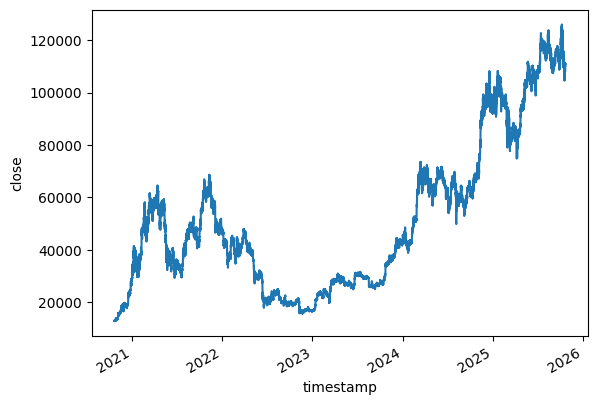

In [34]:
sns.lineplot(x="timestamp", y="close", data=df)
plt.gcf().autofmt_xdate()
plt.show()

In [35]:
last_close = df[df["timestamp"] > "2024-11-01"]

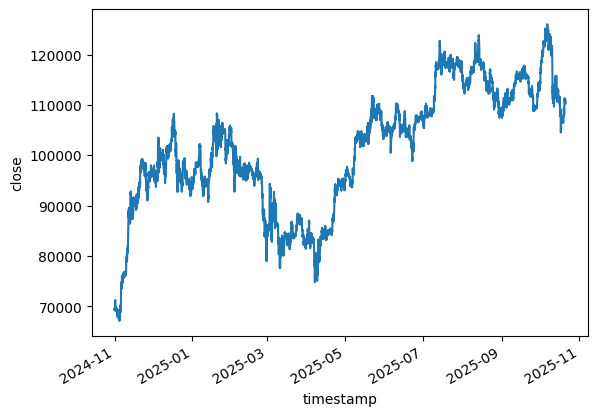

In [36]:
sns.lineplot(x="timestamp", y="close", data=last_close)
plt.gcf().autofmt_xdate()
plt.show()

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43780 entries, 0 to 43779
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  43780 non-null  datetime64[ns]
 1   open       43780 non-null  float64       
 2   high       43780 non-null  float64       
 3   low        43780 non-null  float64       
 4   close      43780 non-null  float64       
 5   volume     43780 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 2.0 MB


In [38]:
df.describe()

,timestamp,open,high,low,close,volume
count,43780,43780.000000,43780.000000,43780.000000,43780.000000,43780.000000
mean,2023-04-22 21:10:15.979899392,51372.757514,51577.929735,51159.339208,51374.983616,3210.633741
min,2020-10-22 02:00:00,12718.260000,12792.990000,12678.080000,12718.260000,0.000000
25%,2022-01-21 21:45:00,27792.845000,27902.302500,27667.737500,27794.820000,805.187030
50%,2023-04-22 23:30:00,43248.020000,43465.670000,43069.690000,43249.225000,1597.695689
75%,2024-07-22 00:15:00,65753.992500,65982.620000,65528.007500,65754.002500,3515.143810
max,2025-10-21 01:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600
std,NaN,28988.464064,29062.404378,28913.627484,28989.246246,4723.875649


# Technical Indicators

### Momentum

In [39]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

### Volume

In [40]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

### Volatility

In [41]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

### Trend

In [42]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

# Data Cleaning

In [43]:
dataset = df.copy()
data_cleaning = DataCleaning()
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

In [44]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-10-23 18:00:00,12785.92,12875.61,12785.92,12852.97,1630.574839,-81.716265,12958.427846,-0.151479,-0.147460,...,77.369044,-19.562495,-0.507294,-19.055201,23.814149,12914.469286,0.902440,1.076557,-0.174118,12896.176476
41,2020-10-23 19:00:00,12852.97,12919.00,12839.12,12918.99,1794.684194,-94.631559,12958.031766,-0.125296,-0.097022,...,77.807683,-16.181539,-3.642143,-12.539396,23.954540,12909.539286,0.948638,1.053871,-0.105233,12896.779238
42,2020-10-23 20:00:00,12919.02,12941.33,12884.28,12927.60,1754.568383,-97.155706,12956.781131,-0.098032,-0.055806,...,77.964532,-12.661399,-5.445994,-7.215405,23.972916,12913.131429,1.016553,1.039185,-0.022632,12899.187333
43,2020-10-23 21:00:00,12928.81,12933.15,12868.01,12904.83,1335.256640,-82.055588,12955.235162,-0.089630,-0.037924,...,78.439383,-11.575575,-6.671910,-4.903665,23.960323,12914.646429,1.004162,0.991829,0.012333,12898.080476
44,2020-10-23 22:00:00,12904.83,12942.92,12891.39,12934.53,1218.466035,-60.063324,12954.902733,-0.063669,-0.009570,...,78.946729,-8.223712,-6.982271,-1.241442,23.730471,12915.867143,1.033815,1.013088,0.020727,12900.731619


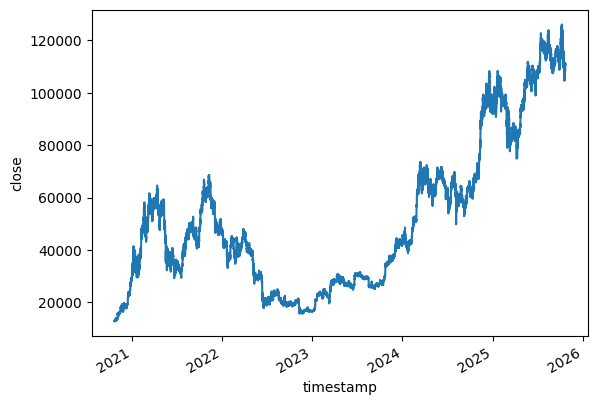

In [45]:
sns.lineplot(x="timestamp", y="close", data=dataset)
plt.gcf().autofmt_xdate()
plt.show()

In [47]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-10-23 18:00:00,12785.92,12875.61,12785.92,12852.97,1630.574839,-81.716265,12958.427846,-0.151479,-0.147460,...,77.369044,-19.562495,-0.507294,-19.055201,23.814149,12914.469286,0.902440,1.076557,-0.174118,12896.176476
41,2020-10-23 19:00:00,12852.97,12919.00,12839.12,12918.99,1794.684194,-94.631559,12958.031766,-0.125296,-0.097022,...,77.807683,-16.181539,-3.642143,-12.539396,23.954540,12909.539286,0.948638,1.053871,-0.105233,12896.779238
42,2020-10-23 20:00:00,12919.02,12941.33,12884.28,12927.60,1754.568383,-97.155706,12956.781131,-0.098032,-0.055806,...,77.964532,-12.661399,-5.445994,-7.215405,23.972916,12913.131429,1.016553,1.039185,-0.022632,12899.187333
43,2020-10-23 21:00:00,12928.81,12933.15,12868.01,12904.83,1335.256640,-82.055588,12955.235162,-0.089630,-0.037924,...,78.439383,-11.575575,-6.671910,-4.903665,23.960323,12914.646429,1.004162,0.991829,0.012333,12898.080476
44,2020-10-23 22:00:00,12904.83,12942.92,12891.39,12934.53,1218.466035,-60.063324,12954.902733,-0.063669,-0.009570,...,78.946729,-8.223712,-6.982271,-1.241442,23.730471,12915.867143,1.033815,1.013088,0.020727,12900.731619


# Feature Engineering

### Timestamp Features

In [48]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

### Lag Features (Targets)

In [49]:
def create_targets(df, target_column='close', n_steps=16):
    
    for step in range(1, n_steps + 1):
        df[f'close_step_{step}'] = df[target_column].shift(-step)
    
    return df

In [50]:
dataset = create_targets(dataset, target_column='close', n_steps=16)

In [51]:
dataset.tail()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,close_step_7,close_step_8,close_step_9,close_step_10,close_step_11,close_step_12,close_step_13,close_step_14,close_step_15,close_step_16
43775,2025-10-20 21:00:00,111091.46,111243.64,110464.91,110563.20,332.06604,924.732000,110553.108818,0.463793,-0.121753,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43776,2025-10-20 22:00:00,110563.20,110867.39,110418.25,110794.08,267.98447,872.274176,110554.431084,0.432933,-0.122090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43777,2025-10-20 23:00:00,110794.08,110828.75,110521.85,110532.09,285.13241,803.610588,110553.644273,0.384939,-0.136067,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43778,2025-10-21 00:00:00,110532.09,110532.09,110168.00,110446.69,437.52159,649.380559,110548.821750,0.336798,-0.147367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43779,2025-10-21 01:00:00,110446.68,110489.41,110128.07,110279.34,185.30649,463.491000,110534.981236,0.283175,-0.160792,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

In [53]:
dataset[["timestamp","close","close_step_1", "close_step_2","close_step_3","close_step_4","close_step_5","close_step_6","close_step_7","close_step_8","close_step_9","close_step_10","close_step_11","close_step_12","close_step_13","close_step_14","close_step_15","close_step_16"]].tail(20)

,timestamp,close,close_step_1,close_step_2,close_step_3,close_step_4,close_step_5,close_step_6,close_step_7,close_step_8,close_step_9,close_step_10,close_step_11,close_step_12,close_step_13,close_step_14,close_step_15,close_step_16
43744,2025-10-19 14:00:00,108405.47,108486.70,108624.19,109113.52,109383.01,108908.43,108845.06,108744.82,109146.80,108642.78,108047.46,108053.58,108767.02,110145.44,110422.10,111033.79,111298.55
43745,2025-10-19 15:00:00,108486.70,108624.19,109113.52,109383.01,108908.43,108845.06,108744.82,109146.80,108642.78,108047.46,108053.58,108767.02,110145.44,110422.10,111033.79,111298.55,111169.92
43746,2025-10-19 16:00:00,108624.19,109113.52,109383.01,108908.43,108845.06,108744.82,109146.80,108642.78,108047.46,108053.58,108767.02,110145.44,110422.10,111033.79,111298.55,111169.92,111097.15
43747,2025-10-19 17:00:00,109113.52,109383.01,108908.43,108845.06,108744.82,109146.80,108642.78,108047.46,108053.58,108767.02,110145.44,110422.10,111033.79,111298.55,111169.92,111097.15,110964.13
43748,2025-10-19 18:00:00,109383.01,108908.43,108845.06,108744.82,109146.80,108642.78,108047.46,108053.58,108767.02,110145.44,110422.10,111033.79,111298.55,111169.92,111097.15,110964.13,110731.78
43749,2025-10-19 19:00:00,108908.43,108845.06,108744.82,109146.80,108642.78,108047.46,108053.58,108767.02,110145.44,110422.10,111033.79,111298.55,111169.92,111097.15,110964.13,110731.78,111016.75
43750,2025-10-19 20:00:00,108845.06,108744.82,109146.80,108642.78,108047.46,108053.58,108767.02,110145.44,110422.10,111033.79,111298.55,111169.92,111097.15,110964.13,110731.78,111016.75,110843.81
43751,2025-10-19 21:00:00,108744.82,109146.80,108642.78,108047.46,108053.58,108767.02,110145.44,110422.10,111033.79,111298.55,111169.92,111097.15,110964.13,110731.78,111016.75,110843.81,111161.35
43752,2025-10-19 22:00:00,109146.80,108642.78,108047.46,108053.58,108767.02,110145.44,110422.10,111033.79,111298.55,111169.92,111097.15,110964.13,110731.78,111016.75,110843.81,111161.35,111210.86
43753,2025-10-19 23:00:00,108642.78,108047.46,108053.58,108767.02,110145.44,110422.10,111033.79,111298.55,111169.92,111097.15,110964.13,110731.78,111016.75,110843.81,111161.35,111210.86,111144.55


# Feature Selection

In [54]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [55]:
dataset = dataset.sort_values('timestamp')

In [56]:
TARGET = ['close_step_1', 'close_step_2', 'close_step_3', 'close_step_4']
DROP_COLUMNS = ['timestamp', 'close_step_1', 'close_step_2', 'close_step_3', 'close_step_4', 'close_step_5', 'close_step_6', 'close_step_7', 'close_step_8', 'close_step_9', 'close_step_10', 'close_step_11', 'close_step_12', 'close_step_13', 'close_step_14', 'close_step_15', 'close_step_16']

In [57]:
def X_y_split(df, target='', drop_columns=[]):
    X = dataset.drop(columns=drop_columns)
    y = dataset[target]
    return X, y

### Feature Importance

In [58]:
xgb_close = XGBRegressor(
    tree_method='hist',
    device='cuda',
    max_bin=256,
    eval_metric='rmse',
)

In [60]:
tscv = TimeSeriesSplit(n_splits=100)

##### Train the model

In [61]:
## Train the model
def model_training(X, y, model, tscv):
    fold_metrics = []
    n = len(X)
    oof_pred = np.full(shape=n, fill_value=np.nan, dtype=float)
    feature_names = X.columns.tolist()
    fold_id = 0
    gain_accum = pd.Series(0.0, index=feature_names)

    for train_idx, val_idx in tscv.split(X):
        fold_id += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        # OOF predictions for this fold’s validation window
        y_val_pred = model.predict(X_test)
        oof_pred[val_idx] = y_val_pred

        # Fold metrics
        rmse = root_mean_squared_error(y_test, y_val_pred)
        mae  = mean_absolute_error(y_test, y_val_pred)
        fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae})

        # Gain importances for this fold (reindexed to all features, missing -> 0)
        gain_dict = model.get_booster().get_score(importance_type="gain")
        gain_fold = pd.Series(gain_dict, dtype=float)

        # xgboost keys are the raw feature names; ensure alignment
        gain_fold.index = [k for k in gain_fold.index]  # no-op but explicit
        gain_fold = gain_fold.reindex(feature_names).fillna(0.0)
        gain_accum += gain_fold

    return fold_metrics, oof_pred, gain_accum


### Feature importance for all the targets

In [71]:
features_by_target = {}
for target in TARGET:
    print(f'Feature importance for {target}')
    X, y = X_y_split(dataset, target=target, drop_columns=DROP_COLUMNS)
    fold_metrics, oof_pred, gain_accum = model_training(X, y, xgb_close, tscv)
    importance_df = (
        gain_accum.div(100)             # average gain across folds
        .sort_values(ascending=False)
        .rename("avg_gain")
        .reset_index()
        .rename(columns={"index": "feature"})
    )
    importance_df["gain_pct"] = (importance_df["avg_gain"] / importance_df["avg_gain"].sum()) * 100
    features_by_target[target] = importance_df[importance_df["gain_pct"] > 0.5]["feature"].tolist()


Feature importance for close_step_1
Feature importance for close_step_2
Feature importance for close_step_3
Feature importance for close_step_4


### Save Selected Features

In [62]:
import joblib
import pickle
import json
import os
from datetime import datetime
model_folder = "saved_models"
os.makedirs(model_folder, exist_ok=True)

In [ ]:
with open('feature_selection/features_by_target_1h_1.json', 'w') as f:
    json.dump(features_by_target, f, indent=4)

### Save Selected Features

In [72]:
import joblib
import pickle
import json
import os
from datetime import datetime
model_folder = "saved_models"
os.makedirs(model_folder, exist_ok=True)

In [73]:
with open('feature_selection/features_by_target_1h_1.json', 'w') as f:
    json.dump(features_by_target, f, indent=4)

# Hyperparameter Tuning

In [74]:
params = {
    "n_estimators": [200, 500, 800, 1000],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10, 15],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.5, 1, 1.5, 2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0, 1, 5, 10],
    "reg_alpha": [0, 0.5, 1, 5]
}

In [75]:
cutoff_date = dataset['timestamp'].quantile(0.8)
close_train = dataset[dataset['timestamp'] < cutoff_date]
close_test = dataset[dataset['timestamp'] >= cutoff_date]

In [76]:
hyperparameter_tuning = RandomizedSearchCV(
    xgb_close, 
    param_distributions=params, 
    n_iter=10, 
    scoring='neg_root_mean_squared_error', 
    cv=tscv, 
    verbose=3,
    n_jobs=2
)

In [77]:
parameters_by_target = {}
for target in TARGET:
    X_close_train = close_train[features_by_target[target]]
    y_close_train = close_train[target]

    split_point = int(len(X_close_train) * 0.8)
    X_train_split = X_close_train[:split_point]
    y_train_split = y_close_train[:split_point]
    X_val_split = X_close_train[split_point:]
    y_val_split = y_close_train[split_point:]

    hyperparameter_tuning.fit(
        X_train_split, 
        y_train_split,
        eval_set=[(X_val_split, y_val_split)],
        verbose=False
    )

    print(f'Best parameters for {target}: {hyperparameter_tuning.best_params_}')
    parameters_by_target[target] = hyperparameter_tuning.best_params_

Fitting 100 folds for each of 10 candidates, totalling 1000 fits
Best parameters for close_step_1: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 5, 'n_estimators': 1000, 'min_child_weight': 10, 'max_depth': 15, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.6}
Fitting 100 folds for each of 10 candidates, totalling 1000 fits
Best parameters for close_step_2: {'subsample': 0.6, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}
Fitting 100 folds for each of 10 candidates, totalling 1000 fits
Best parameters for close_step_3: {'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Fitting 100 folds for each of 10 candidates, totalling 1000 fits
Best parameters for close_step_4: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.5, 'n_estimators': 1000, 'mi

In [78]:
parameters_by_target

{'close_step_1': {'subsample': 0.8,
  'reg_lambda': 10,
  'reg_alpha': 5,
  'n_estimators': 1000,
  'min_child_weight': 10,
  'max_depth': 15,
  'learning_rate': 0.01,
  'gamma': 0.5,
  'colsample_bytree': 0.6},
 'close_step_2': {'subsample': 0.6,
  'reg_lambda': 10,
  'reg_alpha': 1,
  'n_estimators': 800,
  'min_child_weight': 3,
  'max_depth': 5,
  'learning_rate': 0.01,
  'gamma': 0,
  'colsample_bytree': 1.0},
 'close_step_3': {'subsample': 0.6,
  'reg_lambda': 5,
  'reg_alpha': 0,
  'n_estimators': 1000,
  'min_child_weight': 5,
  'max_depth': 3,
  'learning_rate': 0.01,
  'gamma': 0,
  'colsample_bytree': 0.6},
 'close_step_4': {'subsample': 0.8,
  'reg_lambda': 10,
  'reg_alpha': 0.5,
  'n_estimators': 1000,
  'min_child_weight': 3,
  'max_depth': 3,
  'learning_rate': 0.01,
  'gamma': 0.5,
  'colsample_bytree': 1.0}}

### Save Hyper parameters

In [ ]:
with open('hyper_parameter_tuning/parameters_by_target_1h_1.json', 'w') as f:
    json.dump(parameters_by_target, f, indent=4)

# Train the models

In [79]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Performance metrics for close_step_1:
Mean Squared Error (MSE): 962177862.84
Root Mean Squared Error (RMSE): 31018.99
Mean Absolute Error (MAE): 28099.92
R-squared (R2 Score): -3.77
✓ Model saved to: saved_models/xgb_model_close_step_1.joblib


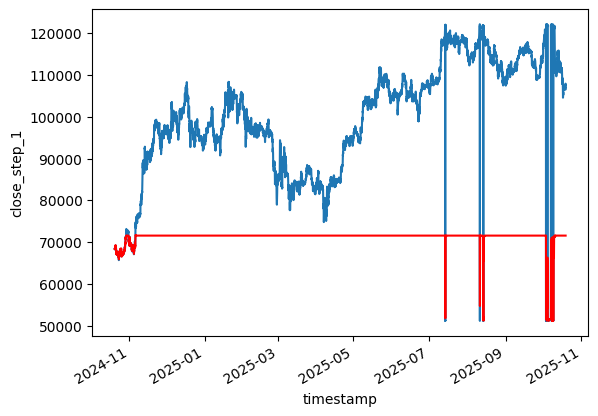

Performance metrics for close_step_2:
Mean Squared Error (MSE): 997586263.35
Root Mean Squared Error (RMSE): 31584.59
Mean Absolute Error (MAE): 28681.05
R-squared (R2 Score): -3.95
✓ Model saved to: saved_models/xgb_model_close_step_2.joblib


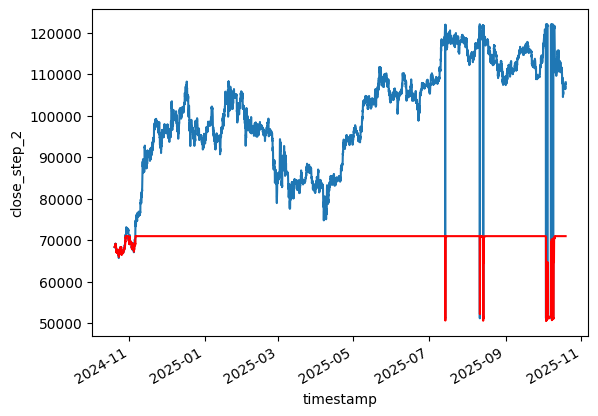

Performance metrics for close_step_3:
Mean Squared Error (MSE): 942353272.00
Root Mean Squared Error (RMSE): 30697.77
Mean Absolute Error (MAE): 27764.70
R-squared (R2 Score): -3.68
✓ Model saved to: saved_models/xgb_model_close_step_3.joblib


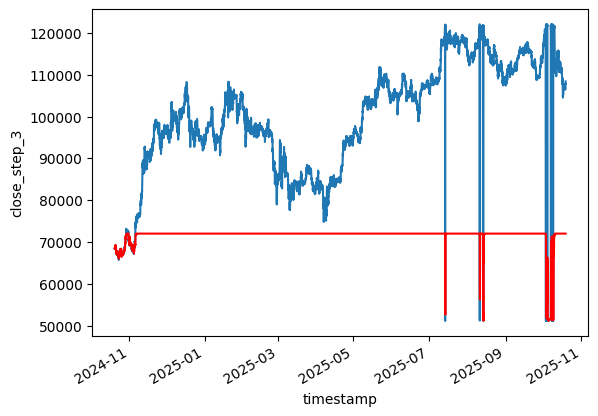

Performance metrics for close_step_4:
Mean Squared Error (MSE): 951823188.01
Root Mean Squared Error (RMSE): 30851.63
Mean Absolute Error (MAE): 27914.59
R-squared (R2 Score): -3.74
✓ Model saved to: saved_models/xgb_model_close_step_4.joblib


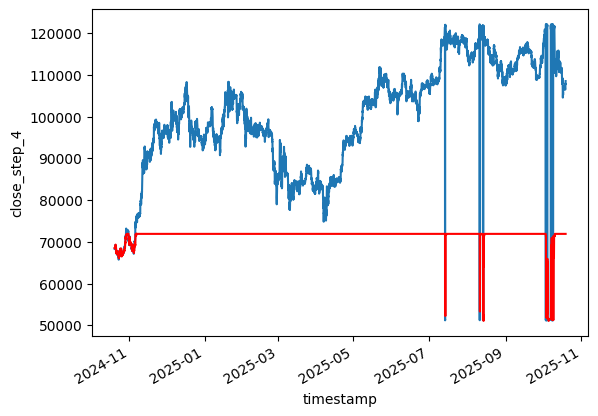

In [ ]:
for target in TARGET:
    X_close_train = close_train[features_by_target[target]]
    y_close_train = close_train[target]
    X_close_test = close_test[features_by_target[target]]
    y_close_test = close_test[target]
    
    split_point = int(len(X_close_train) * 0.8)
    X_train_split = X_close_train[:split_point]
    y_train_split = y_close_train[:split_point]
    X_val_split = X_close_train[split_point:]
    y_val_split = y_close_train[split_point:]

    xgb_open_close = XGBRegressor(
        objective='reg:squarederror', 
        **parameters_by_target[target],
        eval_metric="rmse",
        device='cuda', 
        max_bin=256 
        )

    xgb_open_close.fit(
        X_close_train, 
        y_close_train,
        eval_set=[(X_val_split, y_val_split)],
        verbose=False
    )
    y_pred = xgb_open_close.predict(X_close_test)
    

    print(f"Performance metrics for {target}:")
    mse = mean_squared_error(y_close_test, y_pred)
    rmse = root_mean_squared_error(y_close_test, y_pred)
    mae = mean_absolute_error(y_close_test, y_pred)
    r2 = r2_score(y_close_test, y_pred)

    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R2 Score): {r2:.2f}")

    
    model_filename = f"{model_folder}/xgb_model_1h_{target}.joblib"
    joblib.dump(xgb_open_close, model_filename)
    print(f"✓ Model saved to: {model_filename}")

    dataset_compare = close_test.copy()
    dataset_compare[f'{target}_pred'] = y_pred

    sns.lineplot(x="timestamp", y=target, data=dataset_compare)
    sns.lineplot(x="timestamp", y=f'{target}_pred', data=dataset_compare, color="red")
    plt.gcf().autofmt_xdate()
    plt.show()